In [17]:
import sys
import time
import serial
import  glob
#from jii_multispeq.measurement import measure
#from jii_multispeq.device as device
from matplotlib import pyplot as plt
import numpy as np

In [18]:
# Function to find the connected devices on available serial ports
def findDevice(question="hello", answer="", flush=True, timeout=5):
    """
    Attempts to find Ambit on any available serial port by sending 
    a 'question' string and looking for an 'answer' substring in the response.
    If no matching device is found on any port, implicitly return None

    :param question: The message to send to the device (default: "hello").
    :param answer: The substring we expect in the device's response (default: "").
    :param flush: Whether to flush the serial buffer before sending the question (default: True).
    :param timeout: The read timeout for the serial port in seconds (default: 1).
    :return: The port where the expected 'answer' is found, or None if not found.
    """
    
    def serial_ports():
        """ Lists serial port names

            :raises EnvironmentError:
                On unsupported or unknown platforms
            :returns:
                A list of the serial ports available on the system
        """
        if sys.platform.startswith('win'):
            ports = ['COM%s' % (i + 1) for i in range(256)]
        elif sys.platform.startswith('linux') or sys.platform.startswith('cygwin'):
            # this excludes your current terminal "/dev/tty"
            ports = glob.glob('/dev/tty[A-Za-z]*')
        elif sys.platform.startswith('darwin'):
            ports = glob.glob('/dev/tty.*')
        else:
            raise EnvironmentError('Unsupported platform')

        result = []
        for port in ports:
            try:
                s = serial.Serial(port)
                s.close()
                result.append(port)
            except (OSError, serial.SerialException):
                pass
        return result
    
    for port in serial_ports():     # Iterate through each potential serial port returned by 'serial_ports()'
        with serial.Serial(port, baudrate=115200, timeout=timeout) as ser:         # Open the serial port using a context manager to ensure it closes automatically
            # If flush is True, clear any existing data in the buffer 
            # and give a short delay to stabilize
            if flush:
                #ser.flush()
                ser.reset_input_buffer()
                time.sleep(0.5)
        
            ser.write(question.encode()) # Encode and write the 'question' to the serial port
            time.sleep(0.5) # Allow some time for the device to respond
            
            msg = ser.readline().decode() # Read one line of response from the serial port, then decode it
            
            # If the expected 'answer' substring is in the device response, 
            # print and return the port
            print(f"Received message: {msg.strip()}")
            if answer in msg:
                print(f"Found device at: {port}, answer: {msg}")
                return port
    print("No matching device found.")
    return None  # If no matching device is found, return None
def find_in_tree(obj, *, match_key=None, match_value=None,
                 exist_key=None, return_key=None):
    """
    Search nested lists/dicts.
    - If match_key & match_value are set: collect return_key (or whole dict) from dicts where dict[match_key] == match_value.
    - If exist_key is set: collect return_key (or the value) from dicts that contain exist_key (useful for 'user_answers').
    """
    out = []
    if isinstance(obj, dict):
        # Equality match: e.g., label == "PIRK"
        if match_key is not None and obj.get(match_key) == match_value:
            out.append(obj.get(return_key) if return_key else obj)

        # Presence match: e.g., has key "user_answers"
        if exist_key is not None and exist_key in obj:
            val = obj[exist_key]
            if return_key is None:
                out.append(val)
            elif isinstance(val, dict):
                out.append(val.get(return_key))
            else:
                out.append(None)  # exist_key isn't a dict, can't take return_key

        # Recurse
        for v in obj.values():
            out.extend(find_in_tree(v, match_key=match_key, match_value=match_value,
                                    exist_key=exist_key, return_key=return_key))
    elif isinstance(obj, list):
        for it in obj:
            out.extend(find_in_tree(it, match_key=match_key, match_value=match_value,
                                    exist_key=exist_key, return_key=return_key))
    return out   

In [47]:
# Initialize ports for MiniPAR
PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)

Received message: 
Received message: MiniPAR,V1.1
Found device at: /dev/ttyACM1, answer: MiniPAR,V1.1



In [48]:
# Initi
PORT_DC_SOURCE = findDevice(question="*IDN?\nalize ports for DC supply", answer="KIPRIM", flush=True, timeout=2)

Received message: KIPRIM,DC310S,25011669,FV:V5.2.0
Found device at: /dev/ttyUSB0, answer: KIPRIM,DC310S,25011669,FV:V5.2.0



In [45]:
# Initialize ports for reference sensor TIA (micropython in raw mode)
PORT_REF = findDevice(question="\x01", answer="raw", flush=True, timeout=2, )
with serial.Serial(PORT_REF) as ser:
    ser.write("\x02\x04".encode())
    ser.flush()

Received message: raw REPL; CTRL-B to exit
Found device at: /dev/ttyACM0, answer: raw REPL; CTRL-B to exit



In [75]:
# red referemce
def getPAR_TIA(port):
    with serial.Serial(port) as ser:
        ser.flush()
        ser.write("getPAR()\r".encode())
        response = ser.readline()# skip echo
        #print(response)
        response = ser.readline()
        #print(response)
    return float(response)
    

# read mini Par
def get_par(port, raw=False):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        if raw:
            ser.write("par_raw\n".encode())
        else:
            ser.write("par\n".encode())
        r = ser.readline()
        #print(r)

        return float(r.decode().strip())
        #print(r)

print(get_par(PORT_MINIPAR, raw=True))
print(getPAR_TIA(PORT_REF))



0.1
0.6893559


In [51]:
def set_voltage(port, voltage):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        msg = f"voltage {voltage:.3f}\r\n".encode()
        ser.write(msg)



def set_current(port, current):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        msg = f"current {current:.3f}\r\n".encode()
        ser.write(msg)

#default setup
set_current(port=PORT_DC_SOURCE, current=0.0)
set_voltage(port=PORT_DC_SOURCE, voltage= 25.0)

In [77]:
# clear the callibration coefficient to default
#with serial.Serial(PORT_MINIPAR) as ser:
#    ser.write(f"cal,1.0,0.0\n".encode())
#    print(ser.readline())

# regression curve
currents = [0.2, 0.4, 0.8, 1.0, 1.6, 0]
reference_data = []
sensor_data = []
for I in currents:
    set_current(port=PORT_DC_SOURCE, current=I)
    time.sleep(1.0)
    ref_val = getPAR_TIA(PORT_REF)
    sens_val = get_par(PORT_MINIPAR, raw=True)
    reference_data.append(ref_val)
    sensor_data.append(sens_val)

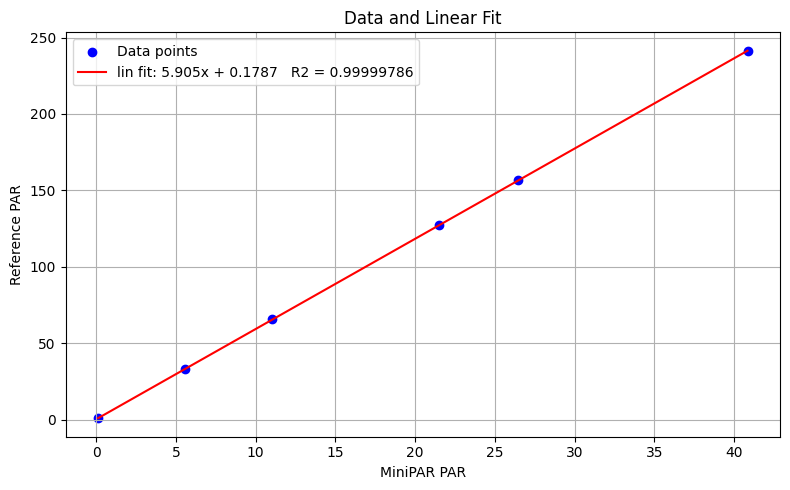

In [78]:
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    return 1 - ss_res / ss_tot

def plot_data_and_fit(x, y, coeffs, r2, output=None, xlabel="x", ylabel="y"):
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color="blue", label="Data points")

    x_sort = np.linspace(np.min(x), np.max(x), 300)
    y_fit = np.polyval(coeffs, x_sort)
    plt.plot(x_sort, y_fit, color="red", label=f"lin fit: {coeffs[0]:.4g}x + {coeffs[1]:.4g}   R2 = {r2:.8g}")

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title("Data and Linear Fit")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    if output:
        plt.savefig(output)
        print(f"Saved plot to {output}")
    plt.show()

y = reference_data
x = sensor_data
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
r2 = r_squared(y, y_pred)

plot_data_and_fit(x,y, coeffs, r2, xlabel="MiniPAR PAR", ylabel="Reference PAR")
#plt.plot(x, y, 'x')

info = ambit_reboot(PORT_AMBIT)
print("Old ambit PAR coefficient:", info.act_led_coeff)
plot_data_and_fit(x,y, coeffs, r2, ylabel="Ambit LED setting", xlabel="MiniPAR PAR")
 


In [82]:
slope = coeffs[0]
offset = coeffs[1]
with serial.Serial(PORT_MINIPAR) as ser:
    ser.write(f"cal_par_slope,{slope:.6g}\n".encode())
    ser.write(f"cal_par_intercept,{offset:.6g}\n".encode())
    print(ser.readline())

set_current(port=PORT_DC_SOURCE, current=0.8)
time.sleep(1.0)

print(getPAR_TIA(port=PORT_REF))
print(get_par(port=PORT_MINIPAR))
set_current(port=PORT_DC_SOURCE, current=0.0)


b'5.90\r\n'
147.17769
148.07


In [ ]:

print(getPAR_TIA(port=PORT_REF))
print(get_par(port=PORT_MINIPAR))


0.59064408
0.75


NameError: name 'par_' is not defined

In [ ]:
def get_MP_name(port):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        ser.write("get_name\n".encode())
        r = ser.readline()
        #print(f"Response from device: {r.decode().strip()}")
        returned_name = r.decode().strip()
        return returned_name

print(get_MP_name(PORT_MINIPAR))

# set Name mini Par
def set_MP_name(port, name="myPar"):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        ser.write(f"set_name,{name}\n".encode())
        r = ser.readline()
        #print(f"Response from device: {r.decode().strip()}")
        returned_name = r.decode().split(":")[1].strip()
        if(returned_name != name):
            print(f"Error setting {name}: {returned_name} returned")

#set_MP_name(PORT_MINIPAR, name="Emit_LED")
set_MP_name(PORT_MINIPAR, name="Par_REF")

Par_REF
